# Data-section figures (rebranded palette)

Recreates Figures 3.1 (per-outlet article-length boxplot, both segment-grouped and median-sorted variants) and 3.2 (weekly article counts per outlet) with:

- Display labels `Antispiegel` (not `Anti-Spiegel`) and `Deutschlandkurier` (not `Deutschland-Kurier`).
- Brand palette: navy `#13436d` (right-extremist), teal `#2da095` (right-conservative), maroon `#7e1b4f` (pro-russian), neutral gray (mainstream).
- Per category, the larger-corpus outlet gets the primary colour, the smaller outlet gets a 50%-white lightened variant.
- Times New Roman throughout.

Outputs go to `01_EDAperOutlet/figures/`.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name and not (PROJECT_ROOT / "2a_NER" / "df_combined.csv").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

DF_PATH = PROJECT_ROOT / "2a_NER" / "df_combined.csv"
FIG_DIR = PROJECT_ROOT / "01_EDAperOutlet" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("project root:", PROJECT_ROOT)
print("data file   :", DF_PATH, "(exists)" if DF_PATH.exists() else "(MISSING)")
print("output dir  :", FIG_DIR)

project root: /Users/MattisHaumann/Dev/Thesis
data file   : /Users/MattisHaumann/Dev/Thesis/2a_NER/df_combined.csv (exists)
output dir  : /Users/MattisHaumann/Dev/Thesis/01_EDAperOutlet/figures


In [2]:
# Times New Roman + light publication rcParams.
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "axes.edgecolor": "black",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "pdf.fonttype": 42,
})

In [3]:
# Brand palette: per-segment primary colour. Pairs share the same primary;
# the smaller outlet in each pair gets the lightened version.
SEGMENT_COLOR = {
    "mainstream":         "#6c757d",  # neutral gray (Tagesschau is alone in this segment)
    "right_extremist":    "#13436d",  # navy   -> Compact (primary), Deutschlandkurier (lighter)
    "right_conservative": "#2da095",  # teal   -> NIUS (primary), Tichys Einblick (lighter)
    "pro_russian":        "#7e1b4f",  # maroon -> RT DE (primary), Antispiegel (lighter)
}

SEGMENT_LABEL = {
    "mainstream":         "Mainstream",
    "right_extremist":    "Right-extremist",
    "right_conservative": "Right-conservative",
    "pro_russian":        "Pro-russian",
}

# source key -> (display label, segment, is_primary)
OUTLETS = {
    "Tagesschau":      ("Tagesschau",        "mainstream",         True),
    "RT_de":           ("RT DE",             "pro_russian",        True),
    "Antispiegel":     ("Antispiegel",       "pro_russian",        False),
    "Compact":         ("Compact",           "right_extremist",    True),
    "Deutschlandkurier":("Deutschlandkurier","right_extremist",    False),
    "Nius":            ("NIUS",              "right_conservative", True),
    "Tichys_Einblick": ("Tichys Einblick",   "right_conservative", False),
}

def lighten(hex_color: str, amount: float = 0.5) -> str:
    """Blend hex_color with white by `amount` (0 = original, 1 = white)."""
    rgb = np.array(mpl.colors.to_rgb(hex_color))
    blended = rgb + (1.0 - rgb) * amount
    return mpl.colors.to_hex(blended)

def color_for(source_key: str) -> str:
    label, seg, is_primary = OUTLETS[source_key]
    base = SEGMENT_COLOR[seg]
    return base if is_primary else lighten(base, 0.45)

OUTLET_COLOR  = {k: color_for(k) for k in OUTLETS}
OUTLET_LABEL  = {k: OUTLETS[k][0] for k in OUTLETS}
OUTLET_LABEL  # quick visual check

{'Tagesschau': 'Tagesschau',
 'RT_de': 'RT DE',
 'Antispiegel': 'Antispiegel',
 'Compact': 'Compact',
 'Deutschlandkurier': 'Deutschlandkurier',
 'Nius': 'NIUS',
 'Tichys_Einblick': 'Tichys Einblick'}

In [4]:
df = pd.read_csv(DF_PATH)
df = df[df["source"].isin(OUTLETS)].copy()
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["display"] = df["source"].map(OUTLET_LABEL)
df["color"]   = df["source"].map(OUTLET_COLOR)
print("rows:", len(df))
print(df["source"].value_counts())

rows: 20440
source
Tagesschau           6320
RT_de                4560
Nius                 3269
Tichys_Einblick      2756
Compact              1486
Deutschlandkurier    1484
Antispiegel           565
Name: count, dtype: int64


## Figure 3.1 - article length per outlet (log-x boxplot, median ordering)

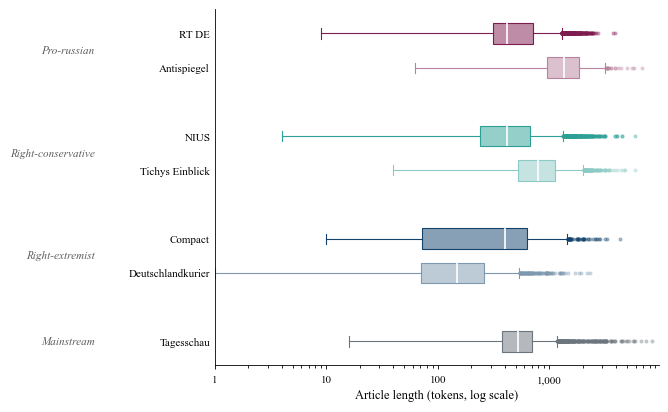

saved: fig_article_length_rebrand.pdf + fig_article_length_rebrand.png


In [5]:
lengths = df.copy()
lengths["tokens"] = lengths["Text"].fillna("").astype(str).str.split().str.len()
lengths = lengths[lengths["tokens"] > 0]

# Group by segment (palette order). Within each segment, primary outlet first
# (darker shade on top), then lighter; ties broken by median length descending.
SEGMENT_ORDER = ["pro_russian", "right_conservative", "right_extremist", "mainstream"]
medians = lengths.groupby("source")["tokens"].median()

ordered = []
for seg in SEGMENT_ORDER:
    seg_outlets = [k for k, (_, s, _) in OUTLETS.items() if s == seg]
    seg_outlets.sort(key=lambda k: (not OUTLETS[k][2], -medians.get(k, 0)))
    ordered.extend(seg_outlets)

# Assign vertical positions, leaving a small gap between segments.
GAP = 1.0  # extra units of vertical space between segments
positions: dict[str, float] = {}
y = 0.0
for i, src in enumerate(ordered):
    if i > 0 and OUTLETS[src][1] != OUTLETS[ordered[i - 1]][1]:
        y += GAP
    positions[src] = y
    y += 1.0
# Flip so the first segment appears at the top of the figure.
max_y = max(positions.values())
positions = {k: max_y - v for k, v in positions.items()}

data    = [lengths.loc[lengths["source"] == src, "tokens"].values for src in ordered]
colors  = [OUTLET_COLOR[src] for src in ordered]
labels  = [OUTLET_LABEL[src] for src in ordered]
y_vals  = [positions[src] for src in ordered]

fig, ax = plt.subplots(figsize=(6.4, 4.0))

bp = ax.boxplot(
    data,
    positions=y_vals,
    vert=False,
    widths=0.6,
    patch_artist=True,
    showfliers=True,
    flierprops=dict(marker="o", markersize=2, linestyle="none", alpha=0.3),
    medianprops=dict(color="white", linewidth=1.2),
    whiskerprops=dict(linewidth=0.8),
    capprops=dict(linewidth=0.8),
    boxprops=dict(linewidth=0.8),
)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(mpl.colors.to_rgba(color, alpha=0.5))
    patch.set_edgecolor(color)
for whisker_pair, color in zip(zip(bp["whiskers"][0::2], bp["whiskers"][1::2]), colors):
    for w in whisker_pair:
        w.set_color(color)
for cap_pair, color in zip(zip(bp["caps"][0::2], bp["caps"][1::2]), colors):
    for c in cap_pair:
        c.set_color(color)
for flier, color in zip(bp["fliers"], colors):
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor(color)

ax.set_xscale("log")
ax.set_xlabel("Article length (tokens, log scale)")
ax.set_xticks([1, 10, 100, 1000, 10000])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_yticks(y_vals)
ax.set_yticklabels(labels)
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", length=3)
ax.set_xlim(max(1, lengths["tokens"].min()), lengths["tokens"].max() * 1.15)
ax.set_ylim(min(y_vals) - 0.7, max(y_vals) + 0.7)

# Italic segment labels on the right edge of the y-axis area.
for seg in SEGMENT_ORDER:
    seg_outlets = [src for src in ordered if OUTLETS[src][1] == seg]
    if not seg_outlets:
        continue
    y_center = np.mean([positions[s] for s in seg_outlets])
    ax.text(
        -0.27,
        y_center,
        SEGMENT_LABEL[seg],
        transform=ax.get_yaxis_transform(),
        ha="right",
        va="center",
        fontsize=8,
        style="italic",
        color="0.35",
    )

fig.subplots_adjust(left=0.30)
plt.tight_layout(pad=0.3)
out_pdf = FIG_DIR / "fig_article_length_rebrand.pdf"
out_png = FIG_DIR / "fig_article_length_rebrand.png"
fig.savefig(out_pdf, bbox_inches="tight")
fig.savefig(out_png, bbox_inches="tight", dpi=300)
plt.show()
print("saved:", out_pdf.name, "+", out_png.name)

## Figure 3.1b - article length per outlet, sorted by median (no segment grouping)

Same data and palette as Figure 3.1, but outlets ordered top-to-bottom by descending median article length. Use whichever ordering fits the surrounding prose; both PDFs save to `data preprocessing/figures/`.

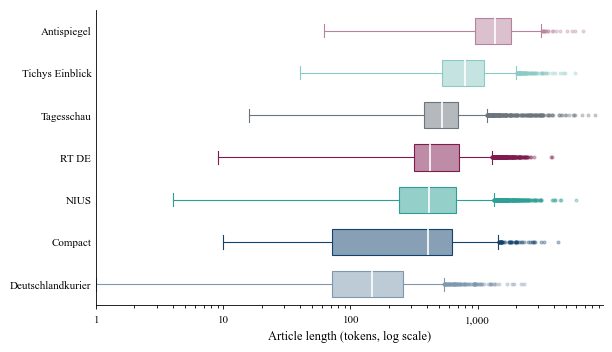

saved: fig_article_length_rebrand_ungrouped.pdf + fig_article_length_rebrand_ungrouped.png


In [6]:
# Ungrouped variant: outlets ordered by median article length (descending).
medians = lengths.groupby("source")["tokens"].median().sort_values(ascending=False)
ordered_u = list(medians.index)

data_u    = [lengths.loc[lengths["source"] == src, "tokens"].values for src in ordered_u]
colors_u  = [OUTLET_COLOR[src] for src in ordered_u]
labels_u  = [OUTLET_LABEL[src] for src in ordered_u]

fig, ax = plt.subplots(figsize=(6.0, 3.4))
positions = np.arange(len(ordered_u))[::-1]

bp = ax.boxplot(
    data_u,
    positions=positions,
    vert=False,
    widths=0.62,
    patch_artist=True,
    showfliers=True,
    flierprops=dict(marker="o", markersize=2, linestyle="none", alpha=0.3),
    medianprops=dict(color="white", linewidth=1.2),
    whiskerprops=dict(linewidth=0.8),
    capprops=dict(linewidth=0.8),
    boxprops=dict(linewidth=0.8),
)
for patch, color in zip(bp["boxes"], colors_u):
    patch.set_facecolor(mpl.colors.to_rgba(color, alpha=0.5))
    patch.set_edgecolor(color)
for whisker_pair, color in zip(zip(bp["whiskers"][0::2], bp["whiskers"][1::2]), colors_u):
    for w in whisker_pair:
        w.set_color(color)
for cap_pair, color in zip(zip(bp["caps"][0::2], bp["caps"][1::2]), colors_u):
    for c in cap_pair:
        c.set_color(color)
for flier, color in zip(bp["fliers"], colors_u):
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor(color)

ax.set_xscale("log")
ax.set_xlabel("Article length (tokens, log scale)")
ax.set_xticks([1, 10, 100, 1000, 10000])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_yticks(positions)
ax.set_yticklabels(labels_u)
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", length=3)
ax.set_xlim(max(1, lengths["tokens"].min()), lengths["tokens"].max() * 1.15)

plt.tight_layout(pad=0.3)
out_pdf = FIG_DIR / "fig_article_length_rebrand_ungrouped.pdf"
out_png = FIG_DIR / "fig_article_length_rebrand_ungrouped.png"
fig.savefig(out_pdf, bbox_inches="tight")
fig.savefig(out_png, bbox_inches="tight", dpi=300)
plt.show()
print("saved:", out_pdf.name, "+", out_png.name)

## Figure 3.2 - weekly article counts per outlet (absolute, with end-of-line labels)

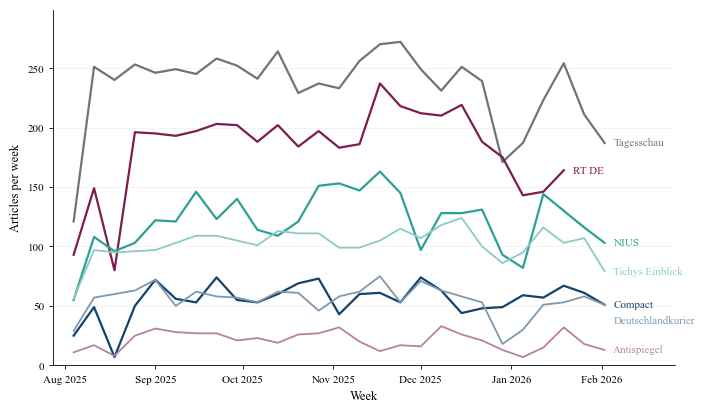

saved: fig_publication_timeline_rebrand.pdf + fig_publication_timeline_rebrand.png


In [7]:
weekly = (
    df.groupby(["source", pd.Grouper(key="Date", freq="W-MON")])
      .size()
      .reset_index(name="count")
)
weekly = weekly[(weekly["Date"] >= "2025-07-28") & (weekly["Date"] <= "2026-02-09")].copy()
weekly["display"] = weekly["source"].map(OUTLET_LABEL)
weekly["color"]   = weekly["source"].map(OUTLET_COLOR)

# Plot order: largest mean weekly count first (so line legibility goes top to bottom).
ordered = (
    weekly.groupby("source")["count"].mean().sort_values(ascending=False).index.tolist()
)

fig, ax = plt.subplots(figsize=(7.0, 4.0))
ax.yaxis.grid(True, color="#EEEEEE", linewidth=0.5, linestyle="-", zorder=0)
ax.set_axisbelow(True)

last_points = []
for src in ordered:
    sub = weekly[weekly["source"] == src].sort_values("Date")
    ax.plot(
        sub["Date"], sub["count"],
        color=OUTLET_COLOR[src],
        linewidth=1.6 if OUTLETS[src][2] else 1.3,
        alpha=1.0,
        zorder=2,
    )
    last = sub.iloc[-1]
    last_points.append({"src": src, "x": last["Date"], "y": float(last["count"])})

# Stack labels so they don't overlap when two outlets end at similar values.
y_max = weekly["count"].max() * 1.1
min_gap = y_max * 0.045
last_points.sort(key=lambda p: p["y"], reverse=True)
last_points[0]["label_y"] = last_points[0]["y"]
for i in range(1, len(last_points)):
    prev_label_y = last_points[i - 1]["label_y"]
    if prev_label_y - last_points[i]["y"] < min_gap:
        last_points[i]["label_y"] = prev_label_y - min_gap
    else:
        last_points[i]["label_y"] = last_points[i]["y"]

for p in last_points:
    ax.text(
        p["x"] + pd.Timedelta(days=3),
        p["label_y"],
        OUTLET_LABEL[p["src"]],
        color=OUTLET_COLOR[p["src"]],
        fontsize=8,
        va="center",
    )

ax.set_ylabel("Articles per week")
ax.set_xlabel("Week")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_xlim(pd.Timestamp("2025-07-28"), pd.Timestamp("2026-02-26"))  # extra room for labels
ax.set_ylim(0, y_max)

plt.tight_layout(pad=0.3)
out_pdf = FIG_DIR / "fig_publication_timeline_rebrand.pdf"
out_png = FIG_DIR / "fig_publication_timeline_rebrand.png"
fig.savefig(out_pdf, bbox_inches="tight")
fig.savefig(out_png, bbox_inches="tight", dpi=300)
plt.show()
print("saved:", out_pdf.name, "+", out_png.name)

## Palette swatch (for reference / legend reuse)

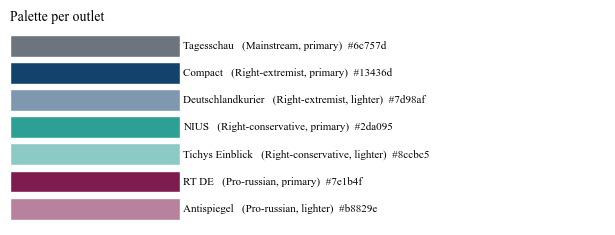

In [8]:
fig, ax = plt.subplots(figsize=(6.0, 2.2))
rows = []
for src, (label, seg, is_primary) in OUTLETS.items():
    rows.append({"label": label, "segment": SEGMENT_LABEL[seg], "primary": is_primary, "color": OUTLET_COLOR[src]})
rows = sorted(rows, key=lambda r: (list(SEGMENT_LABEL.values()).index(r["segment"]), not r["primary"]))

for i, r in enumerate(rows[::-1]):
    ax.barh(i, 1, color=r["color"], edgecolor="white", height=0.8)
    ax.text(1.02, i, f"{r['label']}   ({r['segment']}{', primary' if r['primary'] else ', lighter'})  {r['color']}",
            va="center", ha="left", fontsize=8)
ax.set_xlim(0, 3.5)
ax.set_ylim(-0.6, len(rows) - 0.4)
ax.axis("off")
plt.title("Palette per outlet", fontsize=10, loc="left")
plt.tight_layout(pad=0.2)
plt.show()